In [1]:
pip install pandas numpy matplotlib seaborn plotly


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df = pd.read_csv("Superstore.csv", encoding="latin1")

print(df.head())
print(df.info())
print(df.describe())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [7]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

print("Total Sales: $", round(total_sales,2))
print("Total Profit: $", round(total_profit,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)


Total Sales: $ 2297200.86
Total Profit: $ 286397.02
Total Orders: 5009
Total Customers: 793


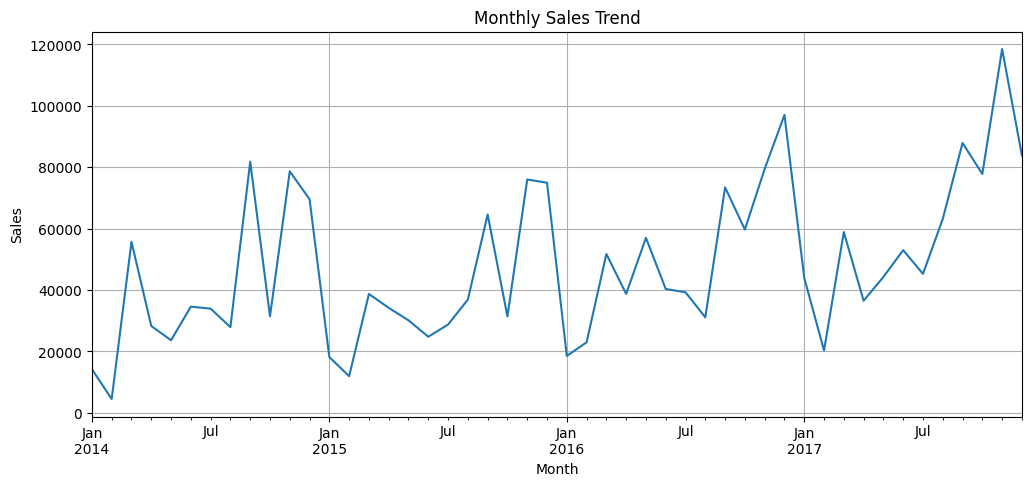

In [8]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


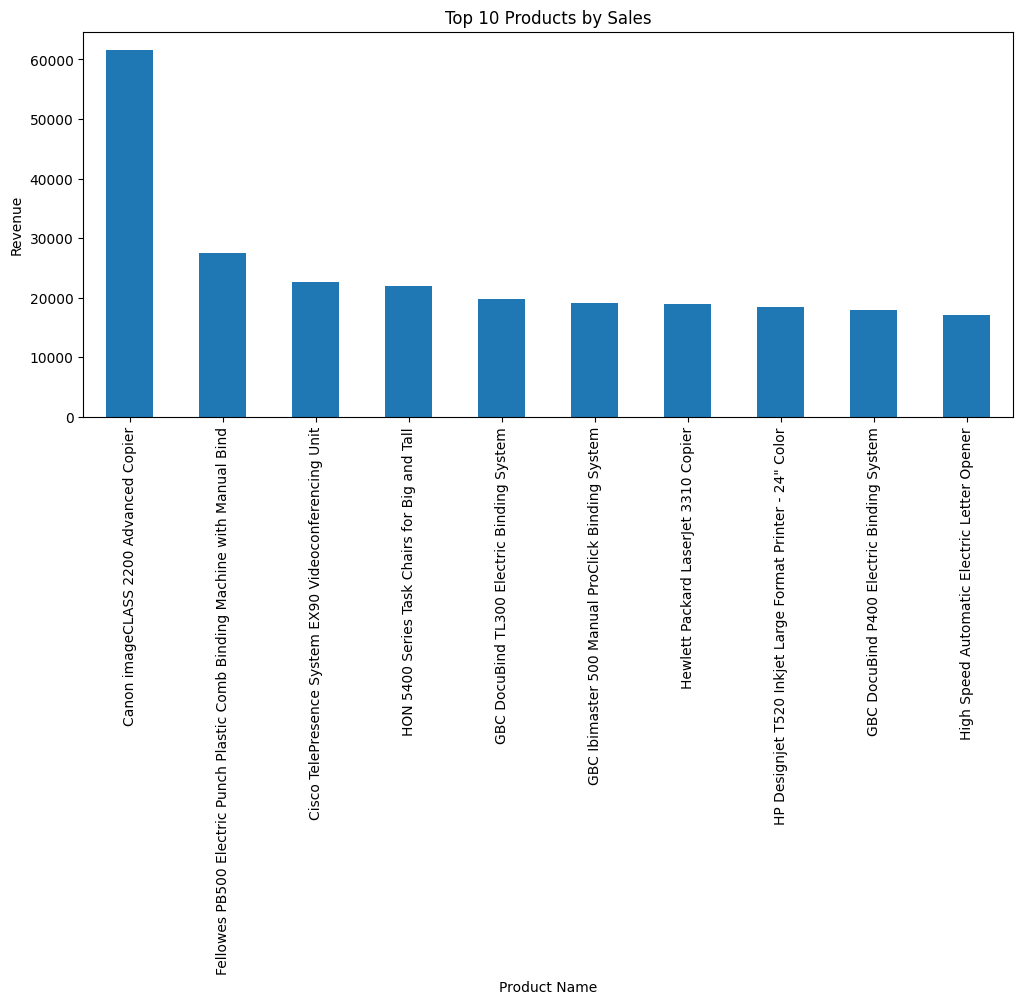

In [9]:
top_products = df.groupby(
    'Product Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

print(top_products)

top_products.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Products by Sales")
plt.ylabel("Revenue")
plt.show()

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


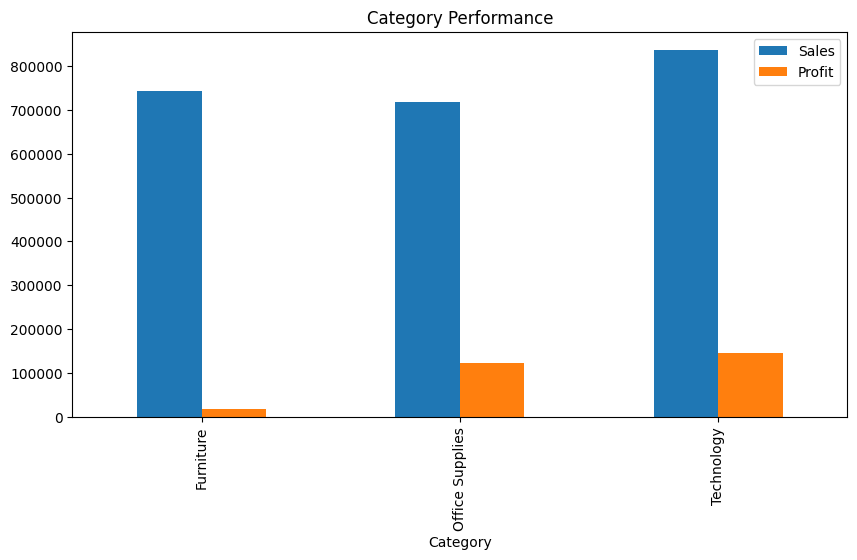

In [10]:
category_sales = df.groupby(
    'Category'
)[['Sales','Profit']].sum()

print(category_sales)

category_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Category Performance")
plt.show()

               Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489


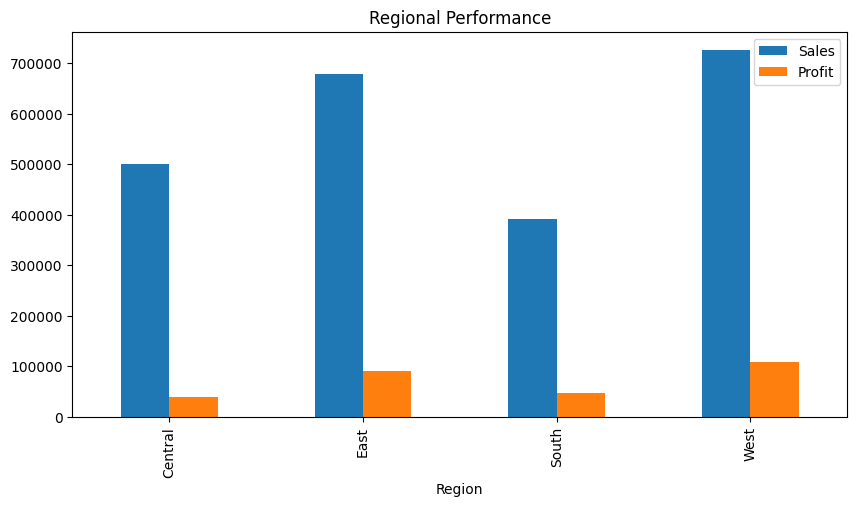

In [11]:
region_sales = df.groupby(
    'Region'
)[['Sales','Profit']].sum()

print(region_sales)

region_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Regional Performance")
plt.show()

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


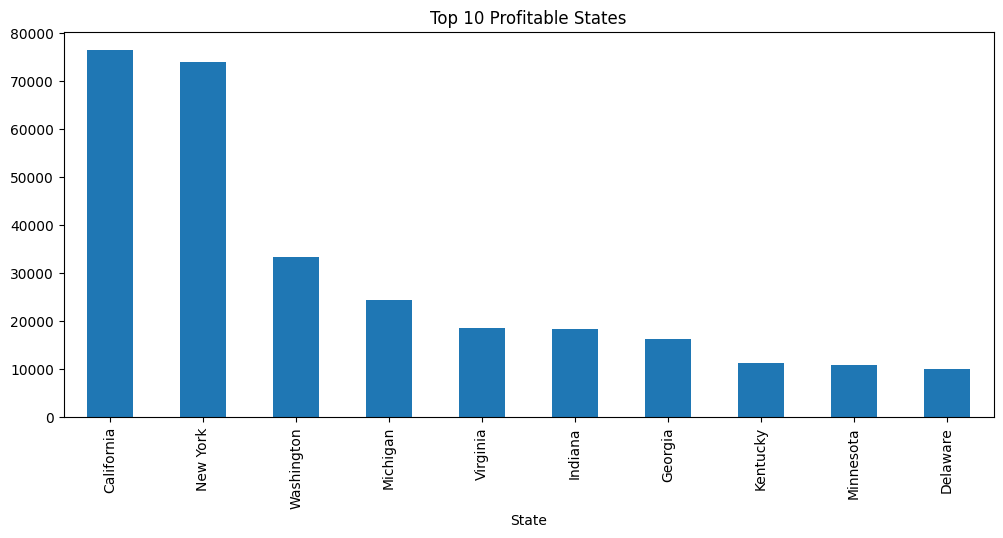

In [12]:
state_profit = df.groupby(
    'State'
)['Profit'].sum().sort_values(
    ascending=False
).head(10)

print(state_profit)

state_profit.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Profitable States")
plt.show()

In [14]:
profit_margin = (
    df['Profit'].sum() /
    df['Sales'].sum()
) * 100

print(
    "Profit Margin:",
    round(profit_margin,2),
    "%"
)

Profit Margin: 12.47 %


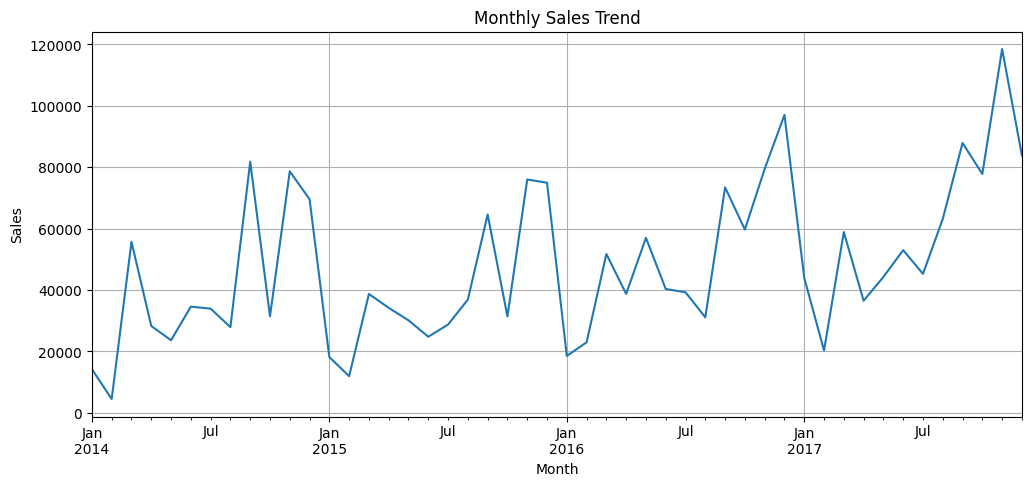

In [18]:
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.savefig("monthly_sales_trend.png", bbox_inches="tight")
plt.show()

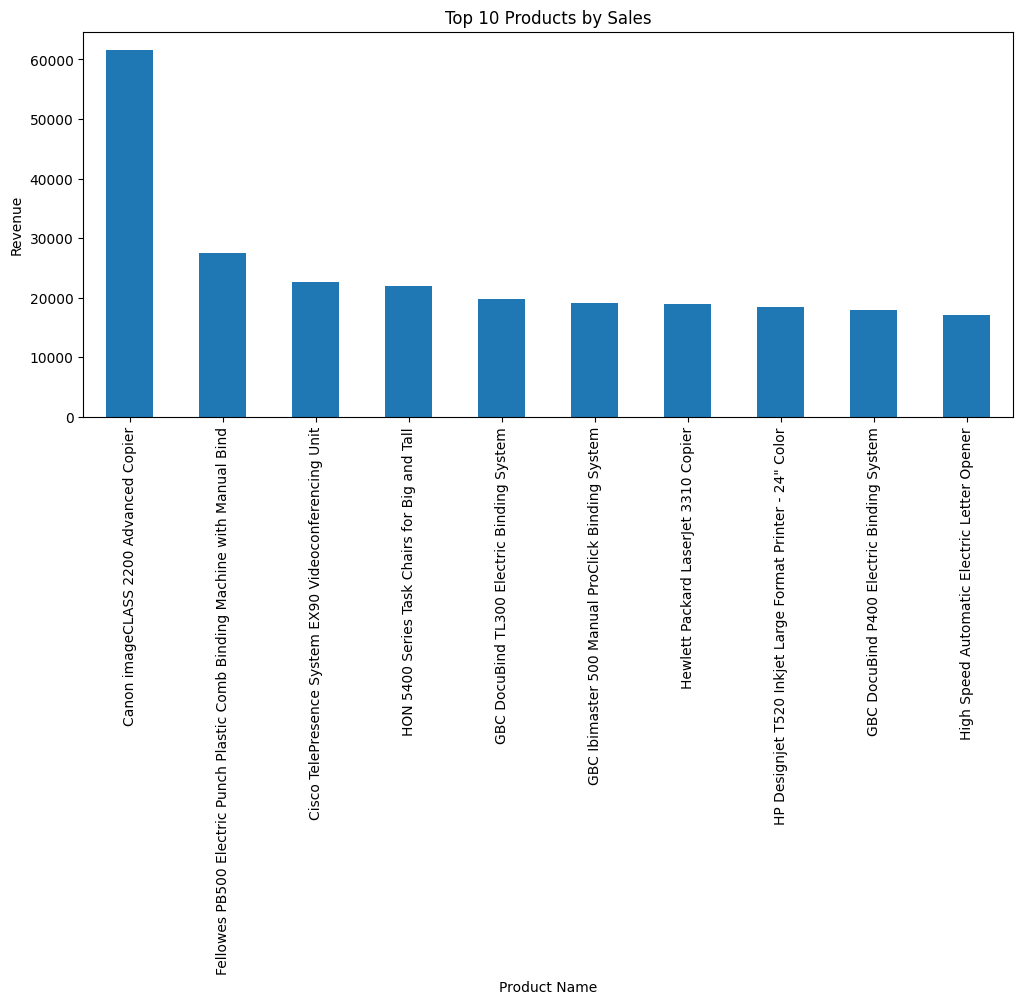

In [20]:
top_products.plot(kind='bar', figsize=(12,5))

plt.title("Top 10 Products by Sales")
plt.ylabel("Revenue")

plt.savefig("top_10_products.png", bbox_inches="tight")
plt.show()

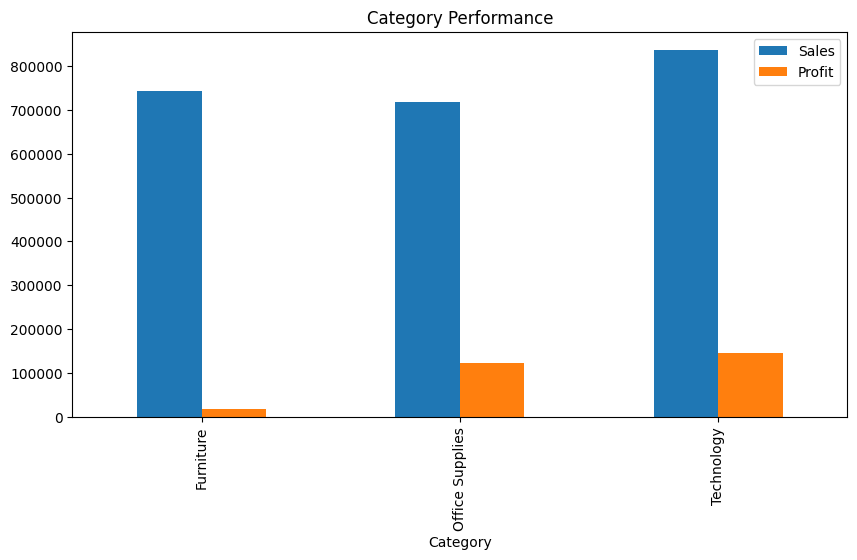

In [21]:
category_sales.plot(kind='bar', figsize=(10,5))

plt.title("Category Performance")

plt.savefig("category_performance.png", bbox_inches="tight")
plt.show()

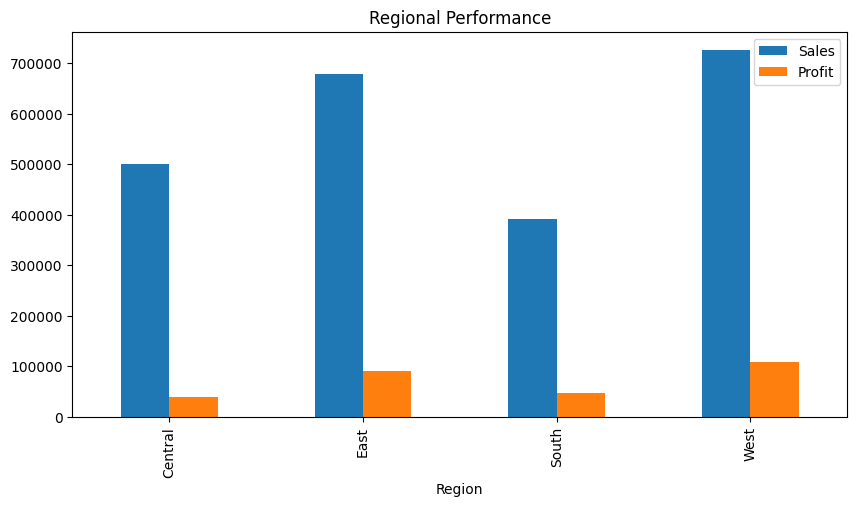

In [23]:
region_sales.plot(kind='bar', figsize=(10,5))

plt.title("Regional Performance")

plt.savefig("regional_performance.png", bbox_inches="tight")
plt.show()

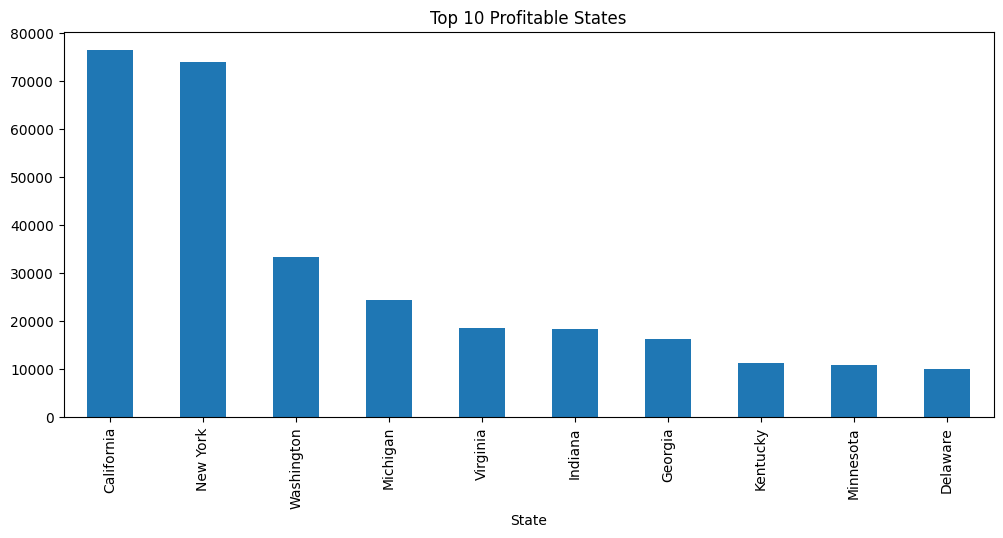

In [24]:
state_profit.plot(kind='bar', figsize=(12,5))

plt.title("Top 10 Profitable States")

plt.savefig("top_profitable_states.png", bbox_inches="tight")
plt.show()